In [1]:
import numpy as np
from pymoo.core.problem import Problem , ElementwiseProblem
from src.modules.MultiCloud import MultiCloud
from src.modules.Cloud import Cloud
from src.modules.Service import Service
from src.modules.commun import Constant
from src.modules.Tools import Tools
from src.modules.Compositon import Composition
import numpy as np
import pandas as pd
from pymoo.core.problem import ElementwiseProblem



services_querry = [0,4,5]
number_Services_Compos = len(services_querry)

MultiCloud_data_dir="./src/data/preprocessedData/NC_20_NS_50/NC_20_NS_50_01"
multicloud = MultiCloud(serviceIds=services_querry , multiCloud_dir=MultiCloud_data_dir)
numberClouds = multicloud.getNumberClouds()


number_clouds = multicloud.getNumberClouds()
numberVar = number_clouds ** number_Services_Compos
pareto_dir = Tools.path_join_folder_and_int_list_csv(Constant.paretosFolder, services_querry)



class SelectService(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=number_Services_Compos,
                         n_obj=Constant.number_objectives,
                         n_ieq_constr=0,
                         xl=np.full(number_Services_Compos,0),
                         xu=np.full(number_Services_Compos,number_clouds-1),
                         vtype=int)
        self.multicloud = multicloud

    def _evaluate(self, x , out, *args, **kwargs):
        services = []
        for i in range(number_Services_Compos):
            cloud = self.multicloud.get_CloudById(int(x[i]))
            service = cloud.get_serviceById(services_querry[i])
            services.append(service)

        composition = Composition(services)
        out["F"] = [ -service_score  for service_score in composition.calculate_score_script()]
        #out["G"] = 0.1 - out["F"]"""

    """def _calc_pareto_front(self):
        data = np.loadtxt(pareto_dir, delimiter=",") * -1
        # Select the last 4 elements from each row
        last = data[:, -Constant.number_objectives:]
        return (last)"""
    
problem = SelectService()



 ./src/data/preprocessedData/NC_20_NS_50/NC_20_NS_50_01 




In [2]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize


from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter


# create the reference directions to be used for the optimization
ref_dirs = get_reference_directions("das-dennis", Constant.number_objectives, n_partitions=8)

# create the algorithm object
algorithm = NSGA3(pop_size=2000,
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=1.0, eta=30.0, vtype=float, repair=RoundingRepair()),
                  mutation=PM(prob=0.7, eta=20.0, vtype=float, repair=RoundingRepair()),
                  eliminate_duplicates=True,
                  ref_dirs=ref_dirs)
            
            
            
            



In [3]:
# execute the optimization
res = minimize(problem,
               algorithm,
               seed=1,
               termination=('n_gen', 15),
               save_history=True,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1775 |     67 |             - |             -
     2 |     3775 |     90 |  0.0778539146 |         ideal
     3 |     5775 |    102 |  0.1182219420 |         ideal
     4 |     7775 |    105 |  0.0152349802 |         ideal
     5 |     9775 |    106 |  0.0048486629 |         ideal
     6 |    11775 |    107 |  0.0045884896 |             f
     7 |    13775 |    109 |  0.0056946764 |             f
     8 |    15775 |    109 |  0.000000E+00 |             f
     9 |    17775 |    109 |  0.000000E+00 |             f
    10 |    19775 |    111 |  0.0160555384 |             f
    11 |    21775 |    111 |  0.000000E+00 |             f
    12 |    23775 |    111 |  0.000000E+00 |             f
    13 |    25775 |    111 |  0.000000E+00 |             f
    14 |    27775 |    111 |  0.000000E+00 |             f
    15 |    29775 |    111 |  0.000000E+00 |             f


The solutions are : 
Pareto front solutions:
[[17  1  0]
 [15  1 15]
 [ 6  6  6]
 [13  7 17]
 [15 13 15]
 [15  8 15]
 [ 8  2 17]
 [10  2 10]
 [ 2  7  7]
 [ 7 13  7]
 [ 0  7  9]
 [10  7  9]
 [ 8  8  8]
 [15  7 12]
 [13 13 17]
 [ 6  4 17]
 [ 0  2  0]
 [ 2  8  8]
 [ 2  2  2]
 [ 9 19  7]
 [ 7  1  7]
 [17  5 17]
 [17  2 17]
 [17  7 17]
 [ 9  1 15]
 [17 17 17]
 [15  1  1]
 [17  1 19]
 [ 7  7  7]
 [12 12  7]
 [ 9  7  7]
 [ 7  1 12]
 [10 19 12]
 [ 8  8 17]
 [ 6  2 19]
 [ 8  2  2]
 [17 13 17]
 [ 7  7 15]
 [ 0  2 17]
 [13  8  8]
 [ 0  8  8]
 [17  7  7]
 [ 1  1  7]
 [ 9  2 15]
 [11 11 11]
 [17  7 11]
 [ 8  8 12]
 [10  7 11]
 [ 0  0  0]
 [17  1 15]
 [12 12 19]
 [15  8 17]
 [15  1 14]
 [ 0 12 15]
 [ 7  7 11]
 [ 0  7  0]
 [12  2  7]
 [ 6  2  2]
 [ 5  5  5]
 [ 7  2  2]
 [ 6  2 11]
 [12 12 15]
 [15 15 15]
 [14 14 14]
 [12  1 17]
 [ 2  2 17]
 [17  1  3]
 [17  4 17]
 [ 3  2 11]
 [17  2  2]
 [ 0 11 11]
 [10  8  8]
 [ 0  7 11]
 [ 9  1  3]
 [ 9  1  2]
 [17  4 19]
 [ 7  2  7]
 [ 7  1  1]
 [11  7 11]
 [ 3  8

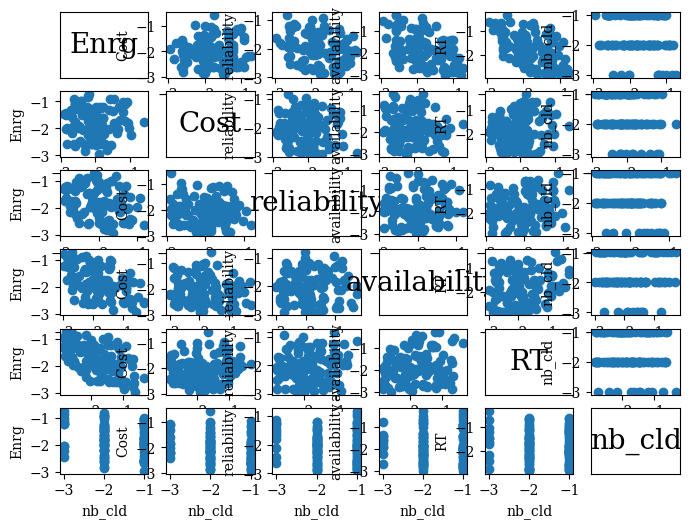

In [4]:
from pymoo.visualization.scatter import Scatter

labels = ["Enrg", "Cost" , "reliability" , "availability","RT", "nb_cld"] 
plot = Scatter(labels=labels)  # Pass labels as an argument
plot.add(res.F)
plot.show()

print("The solutions are : ")
# Access the Pareto front solutions
pareto_front = res.X
pareto_objectives = -res.F

print("Pareto front solutions:")
print(pareto_front)

print("Objective values of the Pareto front solutions:")
print(pareto_objectives)

# Save the solutions to a CSV file
pareto_front_df = pd.DataFrame(pareto_front, columns=[f'var_{i}' for i in range(pareto_front.shape[1])])
pareto_objectives_df = pd.DataFrame(pareto_objectives, columns=[f'obj_{i}' for i in range(pareto_objectives.shape[1])])

# Concatenate decision variables and objectives
solutions_df = pd.concat([pareto_front_df, pareto_objectives_df], axis=1)

# Save to CSV
path_pareto = Tools.path_join_folder_and_int_list_csv(folder_path="./src/data/paretos",int_list=services_querry)
solutions_df.to_csv(path_pareto, index=False)

print("Pareto front solutions saved to nsga2_solutions.csv")

The solutions are : 
Pareto front solutions:
[[17  1  0]
 [15  1 15]
 [ 6  6  6]
 [13  7 17]
 [15 13 15]
 [15  8 15]
 [ 8  2 17]
 [10  2 10]
 [ 2  7  7]
 [ 7 13  7]
 [ 0  7  9]
 [10  7  9]
 [ 8  8  8]
 [15  7 12]
 [13 13 17]
 [ 6  4 17]
 [ 0  2  0]
 [ 2  8  8]
 [ 2  2  2]
 [ 9 19  7]
 [ 7  1  7]
 [17  5 17]
 [17  2 17]
 [17  7 17]
 [ 9  1 15]
 [17 17 17]
 [15  1  1]
 [17  1 19]
 [ 7  7  7]
 [12 12  7]
 [ 9  7  7]
 [ 7  1 12]
 [10 19 12]
 [ 8  8 17]
 [ 6  2 19]
 [ 8  2  2]
 [17 13 17]
 [ 7  7 15]
 [ 0  2 17]
 [13  8  8]
 [ 0  8  8]
 [17  7  7]
 [ 1  1  7]
 [ 9  2 15]
 [11 11 11]
 [17  7 11]
 [ 8  8 12]
 [10  7 11]
 [ 0  0  0]
 [17  1 15]
 [12 12 19]
 [15  8 17]
 [15  1 14]
 [ 0 12 15]
 [ 7  7 11]
 [ 0  7  0]
 [12  2  7]
 [ 6  2  2]
 [ 5  5  5]
 [ 7  2  2]
 [ 6  2 11]
 [12 12 15]
 [15 15 15]
 [14 14 14]
 [12  1 17]
 [ 2  2 17]
 [17  1  3]
 [17  4 17]
 [ 3  2 11]
 [17  2  2]
 [ 0 11 11]
 [10  8  8]
 [ 0  7 11]
 [ 9  1  3]
 [ 9  1  2]
 [17  4 19]
 [ 7  2  7]
 [ 7  1  1]
 [11  7 11]
 [ 3  8

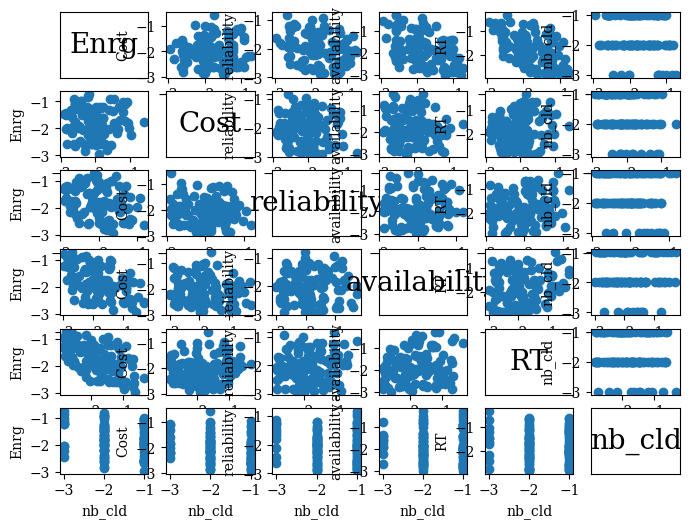

In [5]:
from pymoo.visualization.scatter import Scatter

labels = ["Enrg", "Cost" , "reliability" , "availability","RT", "nb_cld"] 
plot = Scatter(labels=labels)  # Pass labels as an argument
plot.add(res.F)
plot.show()

print("The solutions are : ")
# Access the Pareto front solutions
pareto_front = res.X
pareto_objectives = res.F

print("Pareto front solutions:")
print(pareto_front)

print("Objective values of the Pareto front solutions:")
print(pareto_objectives)

# Save the solutions to a CSV file
pareto_front_df = pd.DataFrame(pareto_front, columns=[f'var_{i}' for i in range(pareto_front.shape[1])])
pareto_objectives_df = pd.DataFrame(pareto_objectives, columns=[f'obj_{i}' for i in range(pareto_objectives.shape[1])])

# Concatenate decision variables and objectives
solutions_df = pd.concat([pareto_front_df, pareto_objectives_df], axis=1)

# Save to CSV
solutions_df.to_csv('nsga3_solutions.csv', index=False)

print("Pareto front solutions saved to nsga3_solutions.csv")

In [6]:
import matplotlib.pyplot as plt


X, F = res.opt.get("X", "F")

hist = res.history
print(len(hist))

hist = res.history
print(len(hist))


n_evals = []             # corresponding number of function evaluations\
hist_F = []              # the objective space values in each generation
hist_cv = []             # constraint violation in each generation
hist_cv_avg = []         # average constraint violation in the whole population

for algo in hist:

    # store the number of function evaluations
    n_evals.append(algo.evaluator.n_eval)
    print(algo.evaluator.n_eval)
    # retrieve the optimum from the algorithm
    opt = algo.opt
    #print(opt)
    # store the least contraint violation and the average in each population
    hist_cv.append(opt.get("CV").min())
    hist_cv_avg.append(algo.pop.get("CV").mean())

    # filter out only the feasible and append and objective space values
    feas = np.where(opt.get("feasible"))[0]
    hist_F.append(opt.get("F")[feas])




15
15
1775
3775
5775
7775
9775
11775
13775
15775
17775
19775
21775
23775
25775
27775
29775


[0.4573470800048565, 0.6114140452501572, 0.6373942442161687, 0.6400826368868406, 0.6418021519239772, 0.6438859398596699, 0.643934161136994, 0.643934161136994, 0.643934161136994, 0.6425302083097651, 0.6425302083097651, 0.6425302083097651, 0.6425302083097651, 0.6425302083097651, 0.6425302083097651]


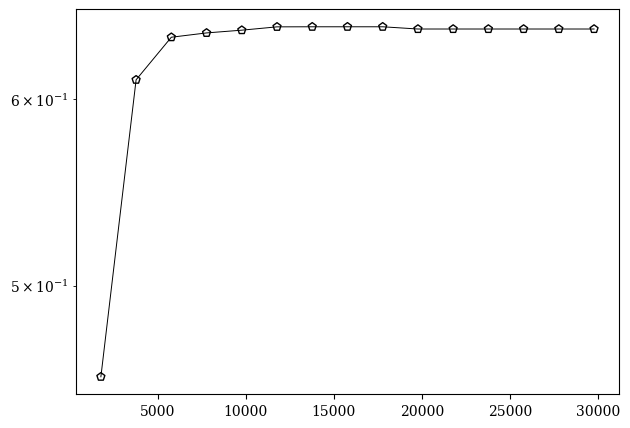

In [7]:

approx_ideal = F.min(axis=0)
approx_nadir = F.max(axis=0)

import matplotlib.pyplot as plt
from pymoo.indicators.hv import Hypervolume

metric = Hypervolume(ref_point= np.full(Constant.number_objectives,1),
                     #norm_ref_point=False,
                     zero_to_one=True,
                     ideal=approx_ideal,
                     nadir=approx_nadir)

hv = [metric.do(_F) for _F in hist_F]
print(hv)
plt.figure(figsize=(7, 5))
plt.plot(n_evals, hv,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, hv,  facecolor="none", edgecolor='black', marker="p")
#plt.title("Convergence")
#plt.xlabel("Function Evaluations")
#plt.ylabel("Hypervolume", fontsize=30)
plt.yscale("log")
plt.savefig(f"./hv_{services_querry[0]}_{services_querry[1]}_{services_querry[2]}")

In [8]:
pf = problem.pareto_front()

from pymoo.indicators.igd import IGD
metric = IGD(pf, zero_to_one=True)

igd = [metric.do(_F) for _F in hist_F]
print(igd)
plt.plot(n_evals, igd,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")
#plt.title("Convergence")
#plt.xlabel("Function Evaluations")
#plt.ylabel("IGD", fontsize=30)
plt.yscale("log")
plt.legend()
plt.savefig(f"./igd_{services_querry[0]}_{services_querry[1]}_{services_querry[2]}")

AssertionError: For normalization either provide pf or bounds!

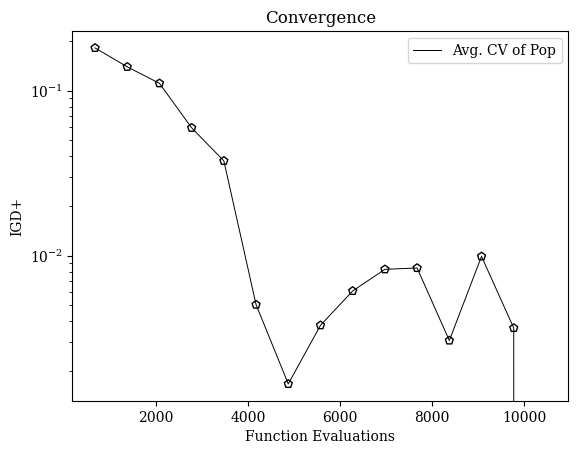

In [ ]:
from pymoo.indicators.igd_plus import IGDPlus

metric = IGDPlus(pf, zero_to_one=True)

igd = [metric.do(_F) for _F in hist_F]

plt.plot(n_evals, igd,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.ylabel("IGD+")
plt.yscale("log")
plt.legend()
plt.show()